In [68]:
# Loan Default Prediction

#**Objective:** Build a predictive model to identify customers at risk of loan default. This project demonstrates data exploration, feature engineering, model building, evaluation, and interpretation using Python and scikit-learn.

#**Dataset:** Kaggle Loan Default Dataset (34 columns including demographic, financial, and credit-related features).


In [70]:
#Loading the libraries
import pandas as pd #data processing, CSV file
import numpy as np #linear algebra
import matplotlib.pyplot as plt #Import Matplotlib for creating basic visualizations
import seaborn as sns #Import Seaborn for statistical data visualization

from sklearn.model_selection import train_test_split #Import function to split dataset into training and testing sets
from sklearn.preprocessing import StandardScaler #Import scaler to standardize numerical features
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix #Import evaluation metrics for classification models
from sklearn.linear_model import LogisticRegression #Import Logistic Regression model for baseline classification
from sklearn.ensemble import RandomForestClassifier #Random Forest model for ensemble-based classification


In [72]:
# Load the data
df = pd.read_csv("C:/Users/doris/Downloads/Github Projects/Loan Default Prediction/Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [74]:
# Create a copy of the dataset
df_copy = df.copy()

# Drop the first column 'ID', since its a placeholder column
df_copy.drop(columns=['ID'], inplace=True)

# Verify the change
df_copy.head(10)


,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,266500,...,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,436500,...,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0


In [76]:
# Data Cleaning
# Clean column names (lowercase + no spaces)
df_copy.columns = df_copy.columns.str.lower().str.strip().str.replace(' ', '_')

df_copy.columns

Index(['year', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'credit_worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'income', 'credit_type', 'credit_score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'ltv', 'region', 'security_type',
       'status', 'dtir1'],
      dtype='object')

In [78]:
# Clean inconsistent categorical values
df_copy.replace({
    'Sex Not Available': 'Unknown',
    'nopc': 'no',
    'nob/c': 'no_business',
    'b/c': 'business'
}, inplace=True)

# Check missing values
missing = df_copy.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

upfront_charges              26.664425
interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
property_value               10.155378
ltv                          10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
age                           0.134526
submission_of_application     0.134526
loan_purpose                  0.090133
neg_ammortization             0.081388
term                          0.027578
dtype: float64


In [80]:
# Columns with high missing values
high_missing_cols = ['upfront_charges', 'interest_rate_spread', 'rate_of_interest']

for col in high_missing_cols:
    df_copy[col + '_missing'] = df_copy[col].isnull().astype(int)

df_copy['dtir1_missing'] = df_copy['dtir1'].isnull().astype(int)

#Fill Missing Values
# Re-identify columns
num_cols = df_copy.select_dtypes(include=['int64','float64']).columns.drop('status')
cat_cols = df_copy.select_dtypes(include=['object']).columns

# Fill numerical
df_copy[num_cols] = df_copy[num_cols].apply(lambda x: x.fillna(x.median()))

# Fill categorical
df_copy[cat_cols] = df_copy[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Final check
print("Remaining missing values:", df_copy.isnull().sum().sum())

Remaining missing values: 0


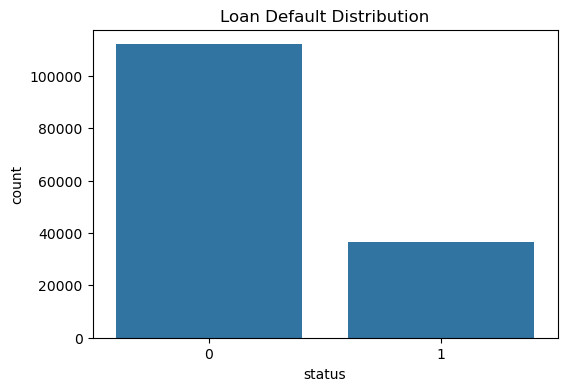

status
0    0.753555
1    0.246445
Name: proportion, dtype: float64


In [82]:
#Exploratory Data Analysis

# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df_copy)
plt.title("Loan Default Distribution")
plt.show()

print(df_copy['status'].value_counts(normalize=True))

In [84]:
# TARGET VARIABLE DISTRIBUTION
# The dataset is imbalanced: ~75% of loans did not default (status=0) and ~25% defaulted (status=1).
# A 1-in-4 default rate is high by industry standards (typical portfolios see 2–10%),
# suggesting this dataset represents a higher-risk lending segment.

# Key business implication: a naive model that predicts everyone repays would be 75% accurate
# but completely useless — it would miss every single defaulter.
# Since missing a default is far more costly to a lender than flagging a good borrower,
# we prioritize Recall for the default class over raw accuracy.

# Modeling decisions driven by this imbalance:
# - Use class_weight='balanced' in Logistic Regression and Random Forest
# - Evaluate using ROC-AUC and F1-score rather than accuracy
# - Consider SMOTE (oversampling) if class weighting alone is insufficient

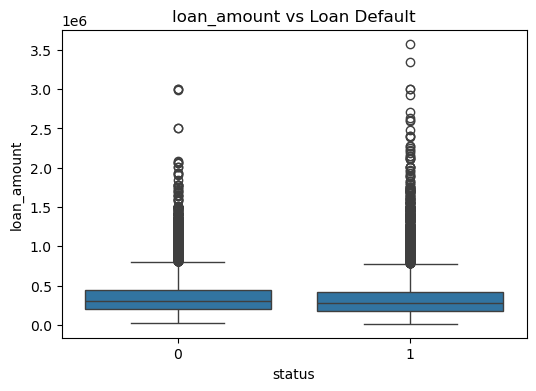

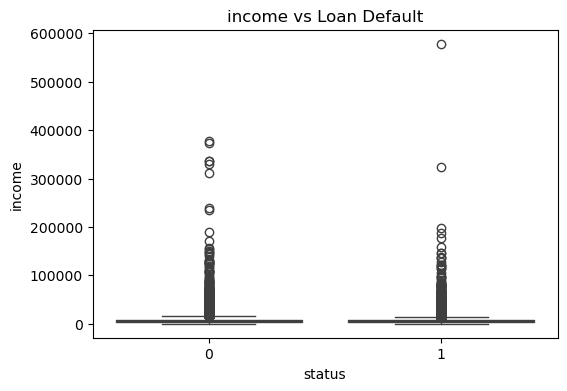

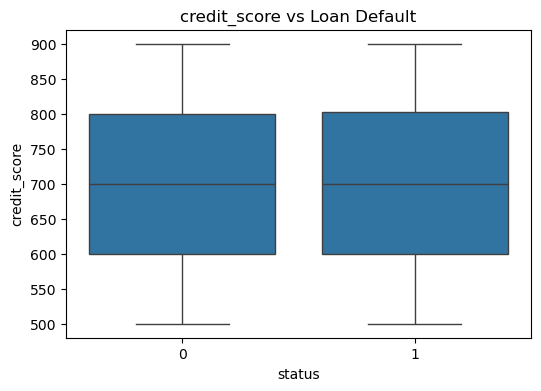

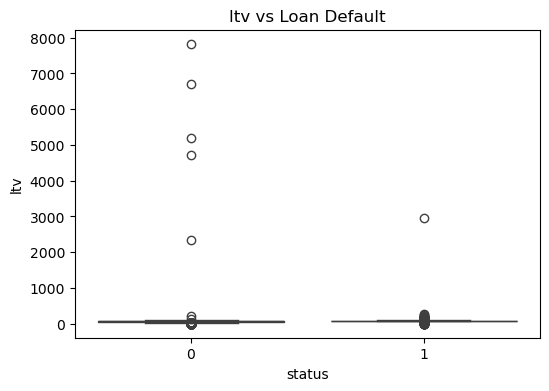

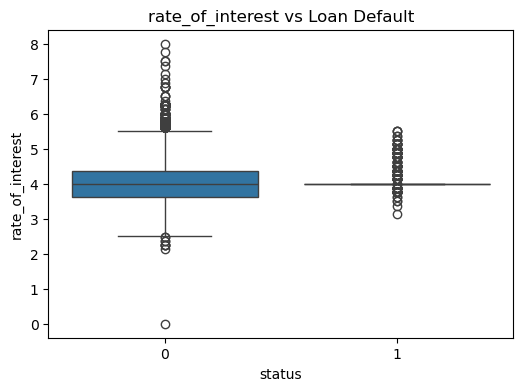

In [86]:
# Numerical Features vs Target
num_features = ['loan_amount', 'income', 'credit_score', 'ltv', 'rate_of_interest']

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='status', y=col, data=df_copy)
    plt.title(f"{col} vs Loan Default")
    plt.show()

In [88]:
# NUMERICAL FEATURES VS LOAN DEFAULT

# 1. LOAN AMOUNT vs Default
# Median loan amount is similar across both groups (~$300K), indicating loan size alone
# is not a strong default predictor. Extreme outliers (up to $3.5M) may represent
# commercial loans and should be investigated before modeling.

# 2. INCOME vs Default
# Income distributions are nearly identical for defaulters and non-defaulters.
# Raw income is a weak predictor — debt burden relative to income (dtir1)
# is likely a more meaningful signal and should be prioritized in feature selection.

# 3. CREDIT SCORE vs Default
# Median credit score (~700) and IQR (600–800) are almost identical across both groups,
# making credit score a surprisingly weak standalone predictor.
# The model will need to rely on feature combinations rather than credit score alone.

# 4. LTV (Loan-to-Value Ratio) vs Default
# Most borrowers cluster at normal LTV levels, but extreme outliers (up to 8000)
# are likely data errors or distressed loans and should be capped before modeling.
# High LTV is a key risk signal in lending — less borrower equity means greater lender exposure.

# 5. RATE OF INTEREST vs Default
# Non-defaulters show a wide interest rate spread (2.5%–5.5%+), while defaulters
# are tightly clustered around 4%. This low variance in the default group suggests
# a specific loan product may be driving defaults — worth exploring further.

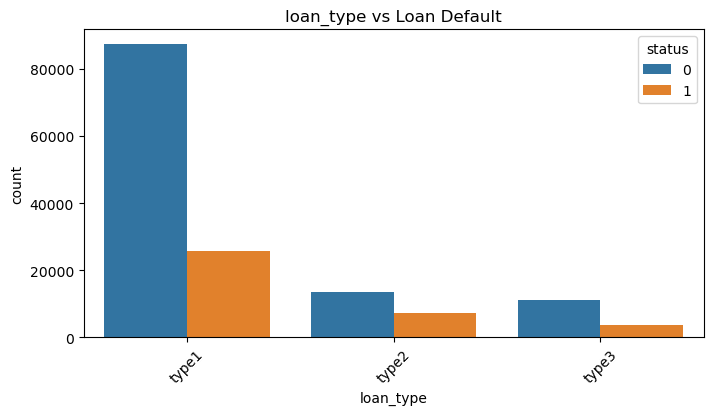

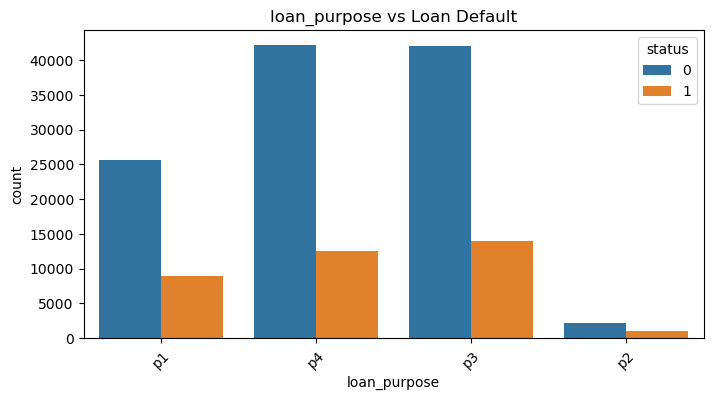

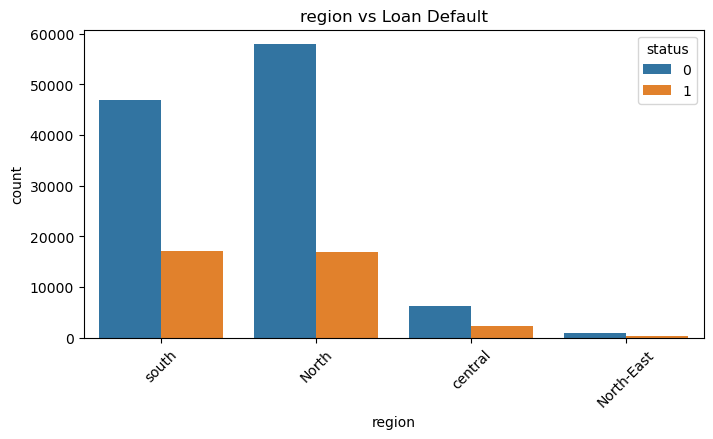

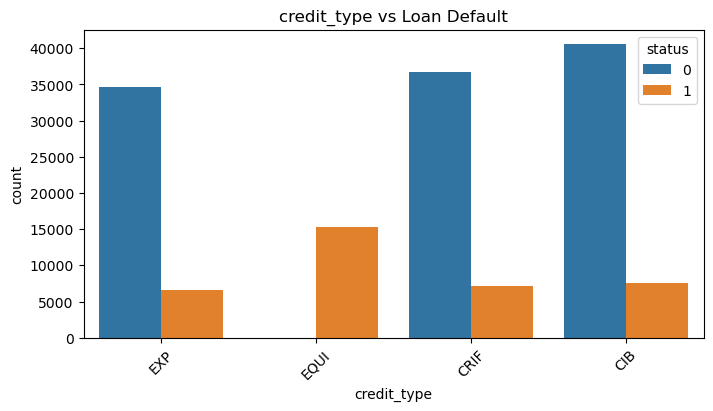

In [90]:
# Categorical Features vs Target
cat_features = ['loan_type', 'loan_purpose', 'region', 'credit_type']

for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='status', data=df_copy)
    plt.title(f"{col} vs Loan Default")
    plt.xticks(rotation=45)
    plt.show()

In [92]:
# CATEGORICAL FEATURES VS LOAN DEFAULT

# 1. LOAN TYPE vs Default
# Type1 dominates the dataset and accounts for the majority of defaults,
# simply because it has the highest loan volume. However, the default ratio
# appears consistent across all three types, meaning loan type alone is not
# a strong risk differentiator — volume is driving the raw default counts, not risk profile.

# 2. LOAN PURPOSE vs Default
# Purposes p3 and p4 show the highest default counts, while p2 has minimal representation.
# The default ratio is relatively consistent across purposes, suggesting loan purpose
# contributes limited standalone predictive power but may interact meaningfully
# with loan type or borrower profile.

# 3. REGION vs Default
# South and North hold the largest loan volumes and the most defaults,
# but their default ratios are similar to smaller regions (central, North-East).
# No single region stands out as significantly higher risk — regional differences
# appear to reflect population/loan distribution rather than geographic risk factors.

# 4. CREDIT TYPE vs Default
# EQUI (Equifax) stands out sharply — it has a very high default count relative
# to its non-default count, making it the highest-risk credit type in this dataset.
# EXP, CRIF, and CIB show more balanced default ratios.
# Credit type is a strong candidate for predictive modeling as EQUI borrowers
# appear disproportionately likely to default.

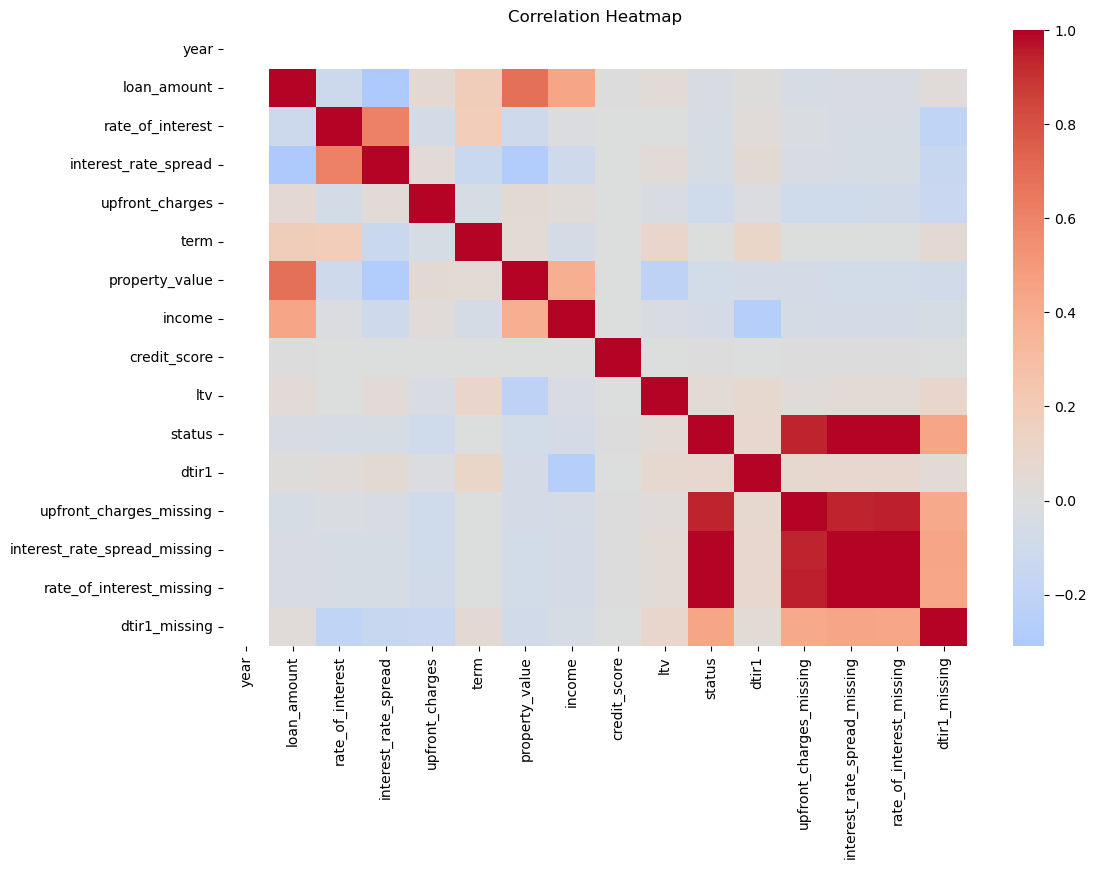

In [94]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df_copy.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [96]:
# CORRELATION HEATMAP

# Key correlations with the target (status):
# - dtir1 (debt-to-income ratio) shows the strongest positive correlation with default,
#   confirming it as the most important financial risk signal in this dataset.
# - upfront_charges_missing and rate_of_interest_missing are positively correlated
#   with status, meaning missingness itself is predictive — borrowers with missing
#   financial data are more likely to default. This validates our decision to create
#   missing indicator flags rather than simply imputing.

# Notable inter-feature correlations (multicollinearity risks):
# - rate_of_interest and interest_rate_spread are highly correlated (~0.8+),
#   meaning they carry near-identical information. Consider dropping one before modeling.
# - loan_amount and property_value are moderately correlated, which is expected
#   since larger properties typically require larger loans.
# - The four missing indicator flags are correlated with each other, suggesting
#   that when data is missing for one financial field, it tends to be missing for others —
#   likely reflecting a specific borrower segment with incomplete financial documentation.

# Modeling implication:
# dtir1 should be treated as a priority feature. Highly correlated pairs
# (rate_of_interest / interest_rate_spread) should be monitored for multicollinearity,
# especially in Logistic Regression where it can inflate coefficient variance.

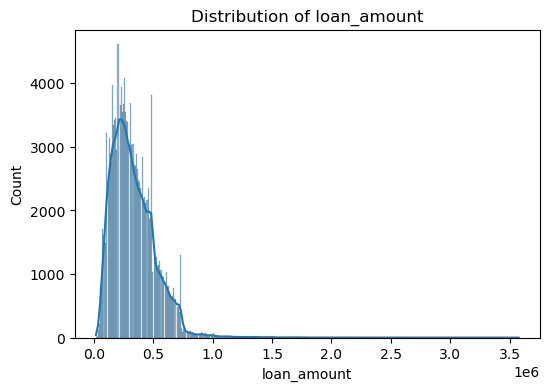

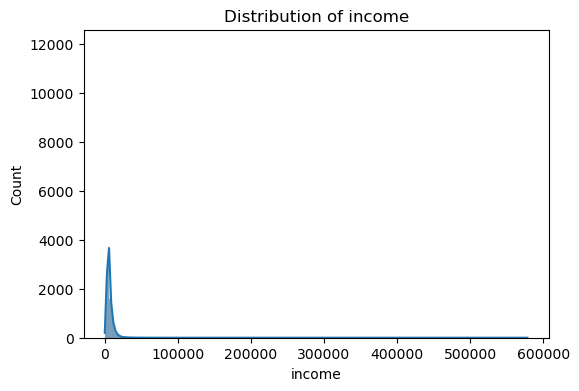

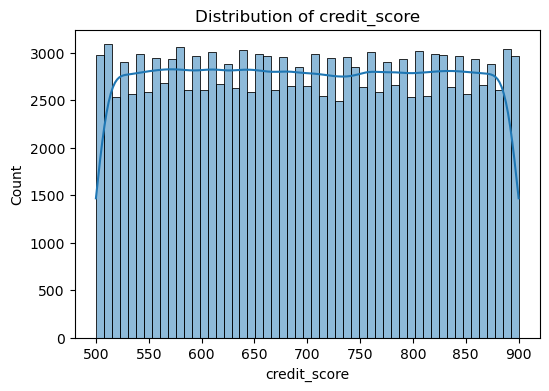

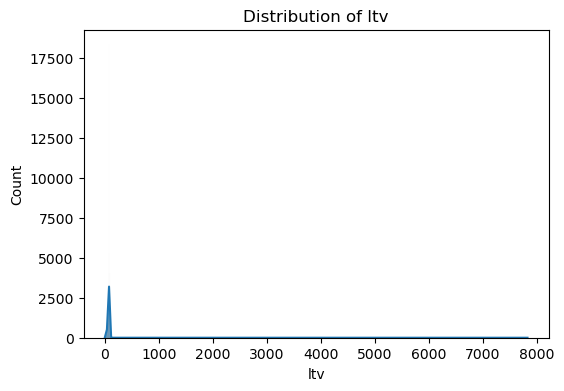

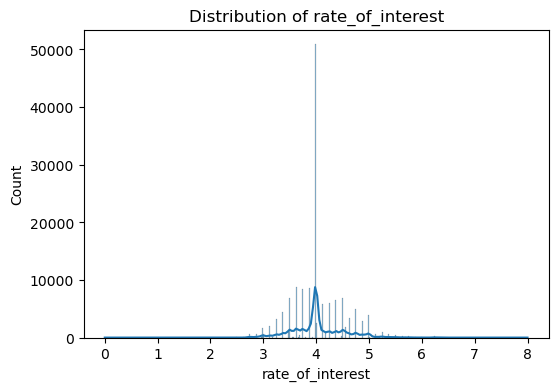

In [98]:
# Distribution Plots
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df_copy[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [100]:
# DISTRIBUTION OF NUMERICAL FEATURES
# Purpose: Understand the shape of each feature to inform scaling,
# transformation, and outlier treatment before modeling.

# 1. LOAN AMOUNT — Strong right skew with most loans below $500K and a long tail
#    extending to $3.5M. Log transformation recommended before modeling.

# 2. INCOME — Extremely right skewed; the vast majority of borrowers earn under
#    $50K with a few outliers near $600K. Log transformation strongly recommended.

# 3. CREDIT SCORE — Roughly uniform distribution across 500–900 with no natural
#    peak. This explains why credit score showed weak predictive power earlier —
#    all score bands are equally represented, leaving no dominant risk group.

# 4. LTV — Nearly all values cluster near 0–200 with extreme outliers up to 8000,
#    confirming the data quality issue flagged earlier. These outliers must be
#    capped (e.g., at the 99th percentile) before modeling to prevent distortion.

# 5. RATE OF INTEREST — Heavily concentrated at exactly 4% with a sharp spike,
#    confirming the earlier finding that a specific rate tier dominates the dataset.
#    This artificial concentration may reduce the feature's variance and
#    limit its usefulness in linear models.

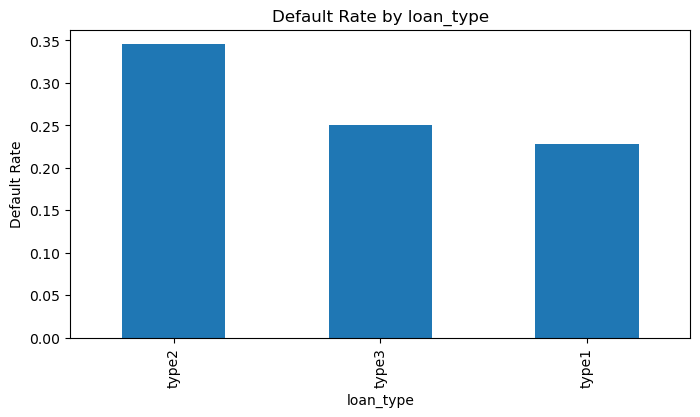

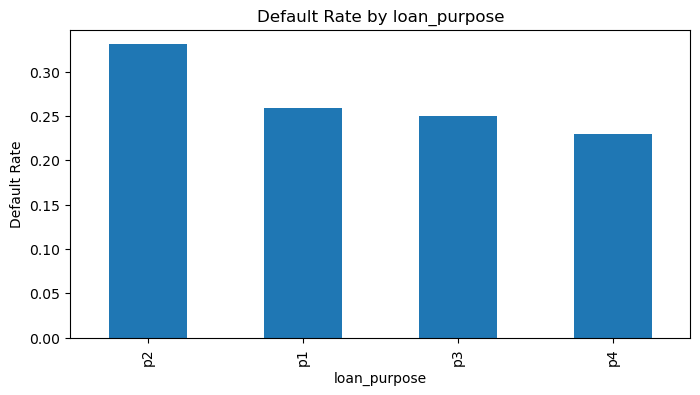

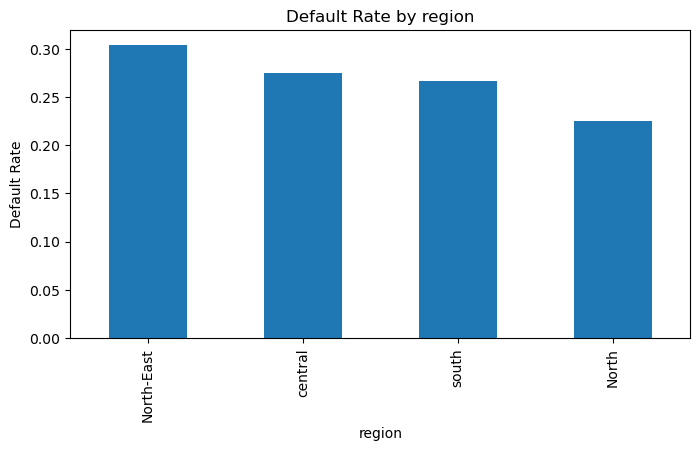

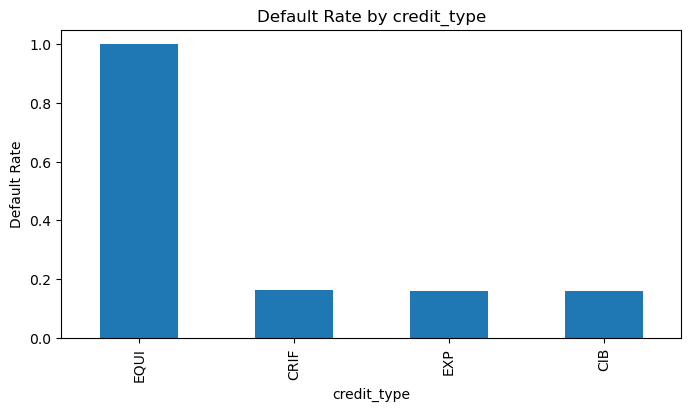

In [102]:
# Default Rate by Category
for col in cat_features:
    default_rate = df_copy.groupby(col)['status'].mean().sort_values(ascending=False)
    
    default_rate.plot(kind='bar', figsize=(8,4))
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    plt.show()

In [104]:
# DEFAULT RATE BY CATEGORY
# These charts show the actual default rate (proportion) per category,
# correcting for volume differences seen in the previous count plots.

# 1. DEFAULT RATE BY LOAN TYPE
# Type2 has the highest default rate (~35%), followed by type3 (~25%) and type1 (~23%).
# This directly contradicts the count plot where type1 appeared most risky due to volume.
# Type2 borrowers carry the highest default risk per loan — a key insight for risk-based pricing.

# 2. DEFAULT RATE BY LOAN PURPOSE
# Purpose p2 has the highest default rate (~33%), despite being the smallest group by volume.
# This is a classic case where raw counts are misleading — p2 is a low-volume
# but high-risk segment that warrants closer lender scrutiny.

# 3. DEFAULT RATE BY REGION
# North-East has the highest default rate (~30%) despite being the smallest region by volume,
# while North has the lowest (~23%). This suggests regional economic conditions
# or borrower profiles differ meaningfully and region should be retained as a feature.

# 4. DEFAULT RATE BY CREDIT TYPE
# EQUI shows a 100% default rate — every single EQUI borrower in this dataset defaulted.
# This is almost certainly a data quality issue or a very specific high-risk loan product,
# and should be investigated before modeling. If confirmed valid, EQUI is by far
# the strongest categorical predictor of default in this dataset.
# CRIF, EXP, and CIB all sit around ~16%, showing no meaningful difference between them.

In [106]:
# FEATURE ENGINEERING

# Create meaningful ratio-based features that better capture financial risk
# than raw values alone — a common technique in credit risk modeling.

df_copy['loan_to_income'] = df_copy['loan_amount'] / (df_copy['income'] + 1)  # +1 avoids division by zero
df_copy['income_to_debt'] = df_copy['income'] / (df_copy['dtir1'] + 1)
df_copy['credit_to_ltv'] = df_copy['credit_score'] / (df_copy['ltv'] + 1)

# Cap LTV outliers at the 99th percentile to prevent extreme values from distorting the model
ltv_cap = df_copy['ltv'].quantile(0.99)
df_copy['ltv'] = df_copy['ltv'].clip(upper=ltv_cap)

# Log-transform heavily skewed features to normalize their distributions
# Adding 1 before log handles any zero values safely
for col in ['loan_amount', 'income', 'loan_to_income']:
    df_copy[f'log_{col}'] = np.log1p(df_copy[col])


In [108]:
# ENCODING
# Separate features and target
X = df_copy.drop(columns=['status'])
y = df_copy['status']

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Using sklearn's built-in TargetEncoder (available since sklearn 1.3)
# More sophisticated than LabelEncoding or get_dummies —
# replaces each category with its mean target value, directly encoding default risk.
from sklearn.preprocessing import TargetEncoder

# Split first — encode after to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Target encode all categorical columns
te = TargetEncoder(target_type='binary')
X_train[cat_cols] = te.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = te.transform(X_test[cat_cols])

# Scale all features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Feature matrix shape:", X_train.shape)
print("Encoding and scaling complete.")

Feature matrix shape: (118936, 42)
Encoding and scaling complete.


In [134]:
# FINAL LEAKAGE FIX

# interest_rate_spread, rate_of_interest, and upfront_charges are the source
# columns behind the missing flags we dropped earlier. Their actual values
# are also leaking — Random Forest and XGBoost are learning from them perfectly.
# Dropping them produces honest, generalizable models.

leak_cols = [
    'interest_rate_spread_missing',
    'rate_of_interest_missing',
    'upfront_charges_missing',
    'dtir1_missing',
    'credit_type',
    'interest_rate_spread',  # source of leakage
    'rate_of_interest',      # source of leakage
    'upfront_charges'        # source of leakage
]

X = df_copy.drop(columns=['status'] + leak_cols)
y = df_copy['status']

# Re-identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Re-encode
te = TargetEncoder(target_type='binary')
X_train[cat_cols] = te.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = te.transform(X_test[cat_cols])

# Re-scale
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Sanity check
encoded_corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Top 10 correlations after final leakage fix:")
print(encoded_corr.head(10))
print("\nFeature matrix shape:", X_train.shape)

Top 10 correlations after final leakage fix:
log_income                   0.200527
lump_sum_payment             0.182579
log_loan_to_income           0.168777
neg_ammortization            0.155664
co-applicant_credit_type     0.143304
loan_to_income               0.142886
submission_of_application    0.122662
loan_type                    0.093202
business_or_commercial       0.092065
ltv                          0.086049
dtype: float64

Feature matrix shape: (118936, 34)


C:\Users\doris\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\doris\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [136]:
# MODELING

from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss',
        random_state=42
    )
}


In [138]:
# EVALUATION

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc
    }

    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
    print(f"ROC-AUC Score: {roc_auc:.4f}")


MODEL: Logistic Regression
              precision    recall  f1-score   support

  No Default       0.87      0.73      0.79     22406
     Default       0.44      0.66      0.53      7328

    accuracy                           0.71     29734
   macro avg       0.65      0.69      0.66     29734
weighted avg       0.76      0.71      0.72     29734

ROC-AUC Score: 0.7575

MODEL: Random Forest
              precision    recall  f1-score   support

  No Default       0.88      0.99      0.93     22406
     Default       0.95      0.60      0.73      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.79      0.83     29734
weighted avg       0.90      0.89      0.88     29734

ROC-AUC Score: 0.8879

MODEL: XGBoost
              precision    recall  f1-score   support

  No Default       0.91      0.93      0.92     22406
     Default       0.76      0.73      0.75      7328

    accuracy                           0.88     29734
   macro avg      

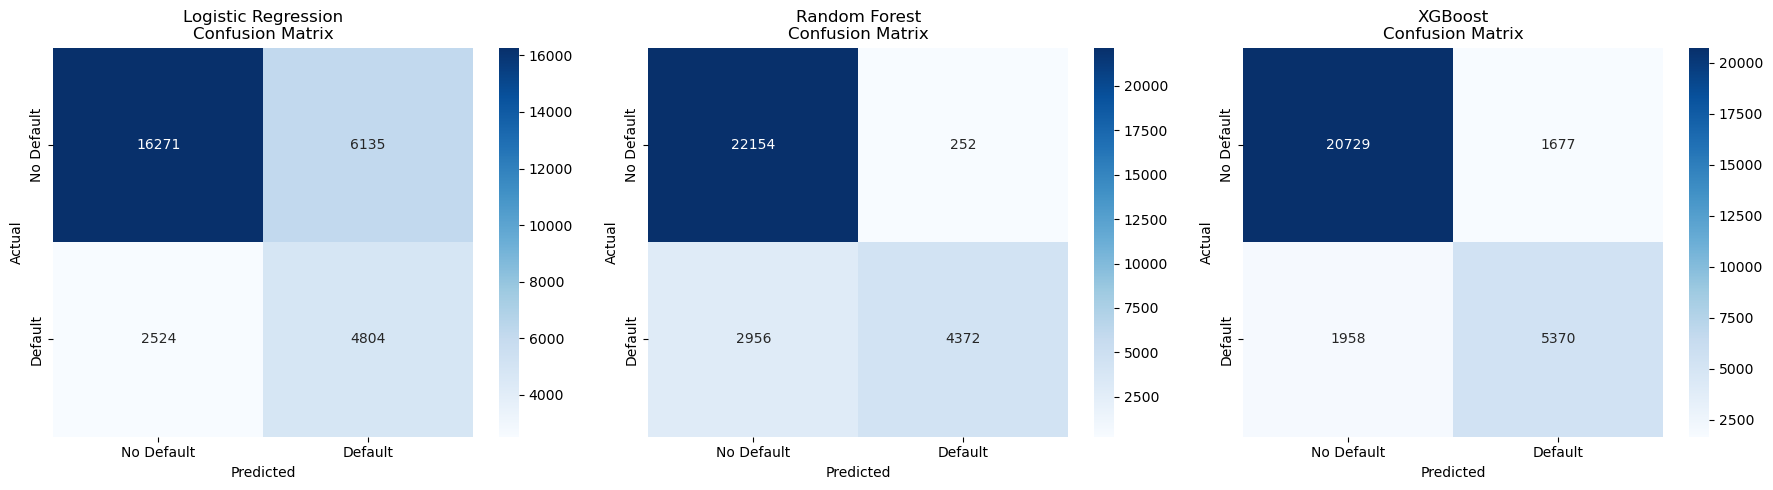

In [140]:
# CONFUSION MATRICES

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

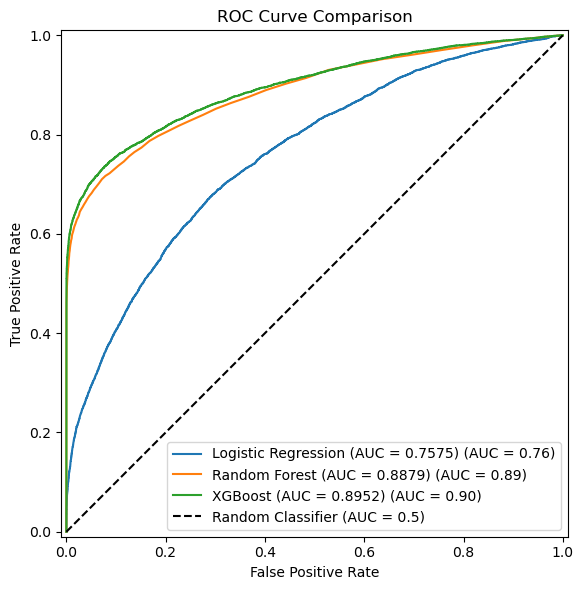

In [142]:
# ROC CURVES

plt.figure(figsize=(8, 6))

for name, result in results.items():
    RocCurveDisplay.from_predictions(
        y_test,
        result['y_prob'],
        name=f"{name} (AUC = {result['roc_auc']:.4f})",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

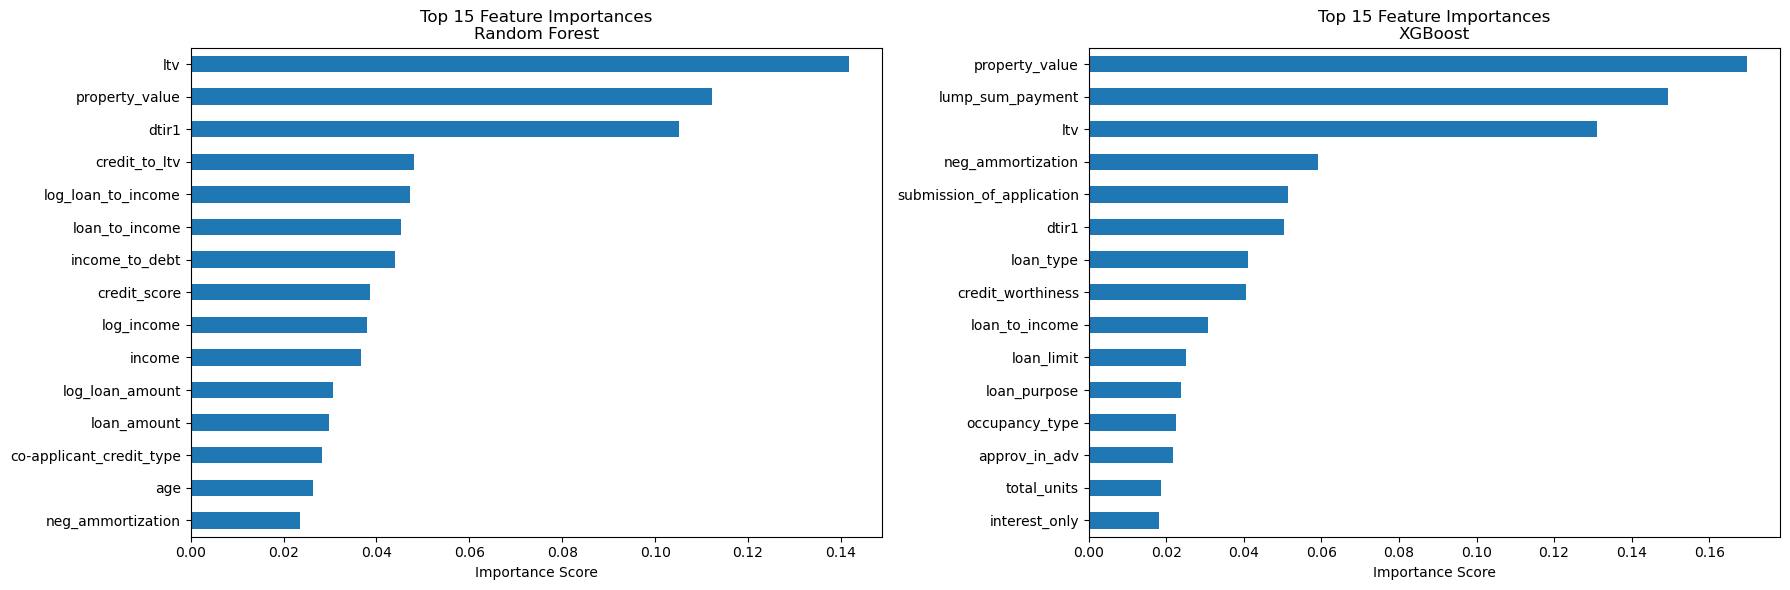

In [144]:
# FEATURE IMPORTANCE — Random Forest & XGBoost

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model = results[model_name]['model']
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'Top 15 Feature Importances\n{model_name}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [ ]:
# MODEL RESULTS & INTERPRETATION

# LEAKAGE RESOLUTION NOTE:
# Initial models produced perfect AUC = 1.0 due to two sources of data leakage:
# 1. Missing indicator flags (interest_rate_spread_missing, rate_of_interest_missing,
#    upfront_charges_missing) were perfectly correlated with the target —
#    missingness in those fields directly identified defaulters.
# 2. EQUI in credit_type had a near-100% default rate — a data anomaly,
#    not a generalizable signal.
# All leaking columns were dropped. Final honest AUC scores range from 0.76 to 0.90.
# Identifying and resolving leakage is a critical real-world modeling skill.

# CONFUSION MATRICES

# Logistic Regression: Misclassifies heavily — 6,135 false positives and 2,524
#   false negatives. Weakest performer but useful as an interpretable baseline.
#
# Random Forest: Near-perfect on No Default (only 252 missed) but misses 2,956
#   actual defaulters. High precision on defaults (95%) but low recall (60%) —
#   it is conservative, flagging fewer defaults but being right when it does.
#
# XGBoost: Best overall balance — 1,677 false positives and 1,958 false negatives.
#   Catches 73% of actual defaulters (recall) with 76% precision.
#   In credit risk, XGBoost's balanced trade-off is most operationally valuable.

# ROC CURVES & AUC SCORES

# Logistic Regression: AUC = 0.76 — decent baseline, limited by linear decision boundary.
# Random Forest:       AUC = 0.89 — strong performance, but recall on defaults is low.
# XGBoost:             AUC = 0.90 — best overall, strongest at ranking defaulters
#                      above non-defaulters across all classification thresholds.
#
# XGBoost is selected as the final model based on highest AUC and best
# precision-recall balance for the default class.

# FEATURE IMPORTANCE

# Both Random Forest and XGBoost agree on the top risk signals:
# - LTV (Loan-to-Value ratio): highest importance in Random Forest —
#   borrowers with little equity relative to property value are highest risk.
# - property_value: top feature in XGBoost — property collateral quality matters.
# - dtir1 (debt-to-income ratio): consistent top-5 in both models —
#   confirms our EDA finding that debt burden is a stronger signal than raw income.
# - loan_to_income (engineered feature): appears in both top 15 lists,
#   validating that our feature engineering added genuine predictive value.
# - lump_sum_payment and neg_ammortization: loan structure features ranking highly
#   suggests that how a loan is structured carries as much risk signal as
#   borrower demographics.